# **📊 EXPLORATORY DATA ANALYTICS**


---
### **1. IMPORTING MODULES**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
console = Console()
from rich.table import Table
table = Table()

---
### **2. LOADING TRAIN DATASET**

In [3]:
# read CSV to dataframe for train dataset
train_df = pd.read_csv(r"..\Processed Datasets\final_train.csv")

# Random 5 rows for the the starting of train dataset
train_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,pos_avg_dpd,pos_max_dpd,pos_avg_dpd_def,pos_max_dpd_def,pos_late_payment_count,pos_serious_dpd_count,pos_active_contracts,pos_completed_contracts,pos_signed_contracts,pos_demand_contracts
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,26.0,2.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,18.0,2.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,62.0,3.0,1.0,0.0


---
### **3. TRAIN DATASET INFORMATION**

In [4]:
# Essential Details of the train dataset
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 239 entries, SK_ID_CURR to pos_demand_contracts
dtypes: float64(182), int64(41), str(16)
memory usage: 599.7 MB


---
### **4. LOADING TEST DATASET**

In [5]:
# read CSV to dataframe for test dataset
test_df = pd.read_csv(r"..\Processed Datasets\final_test.csv")

# Random 5 rows for the the starting of test dataset
train_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,pos_avg_dpd,pos_max_dpd,pos_avg_dpd_def,pos_max_dpd_def,pos_late_payment_count,pos_serious_dpd_count,pos_active_contracts,pos_completed_contracts,pos_signed_contracts,pos_demand_contracts
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,26.0,2.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,18.0,2.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,62.0,3.0,1.0,0.0


---
### **5. TEST DATASET INFORMATION**

In [6]:
# Essential Details of the testdataset
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 238 entries, SK_ID_CURR to pos_demand_contracts
dtypes: float64(182), int64(40), str(16)
memory usage: 94.7 MB


---
### **6. PLOTTING MISSING VALUES IN BAR GRAPH**

In [7]:
# Made a custom function to plot the missing value percentage for train/test datasets
def Missing_value_plotter(dataset, xlabel, ylabel, title):    

    # Storing missing value count of all features
    missing = dataset.isna().sum().sort_values(ascending=False)
    # Storing features having missing value count > 0
    missing = missing[missing > 0]
    # storing the missing value percentage of all features
    missing_pct = (
        dataset.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    # Storing the missing value percentage of the features stored in 'missing'
    missing_pct = missing_pct[missing.index]
    # fig size of 17, length of missing values and 0.2 is for some extra space
    plt.figure(figsize=(17, max(5, len(missing) * 0.2)))
    plt.margins(y=0.001)

    bars = plt.barh(missing.index, missing.values, color=["#5ACCB3", "#6EB5D6", "#D44E4E", "#A8E76D", "#905EBE"])

    for bar, pct in zip(bars, missing_pct):
        plt.text(
            bar.get_width() + missing.max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{pct:.2f}%",
            va="center",
            fontsize=9,
            fontweight="bold"
        )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title, fontsize = 16, fontweight = 'bold')
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

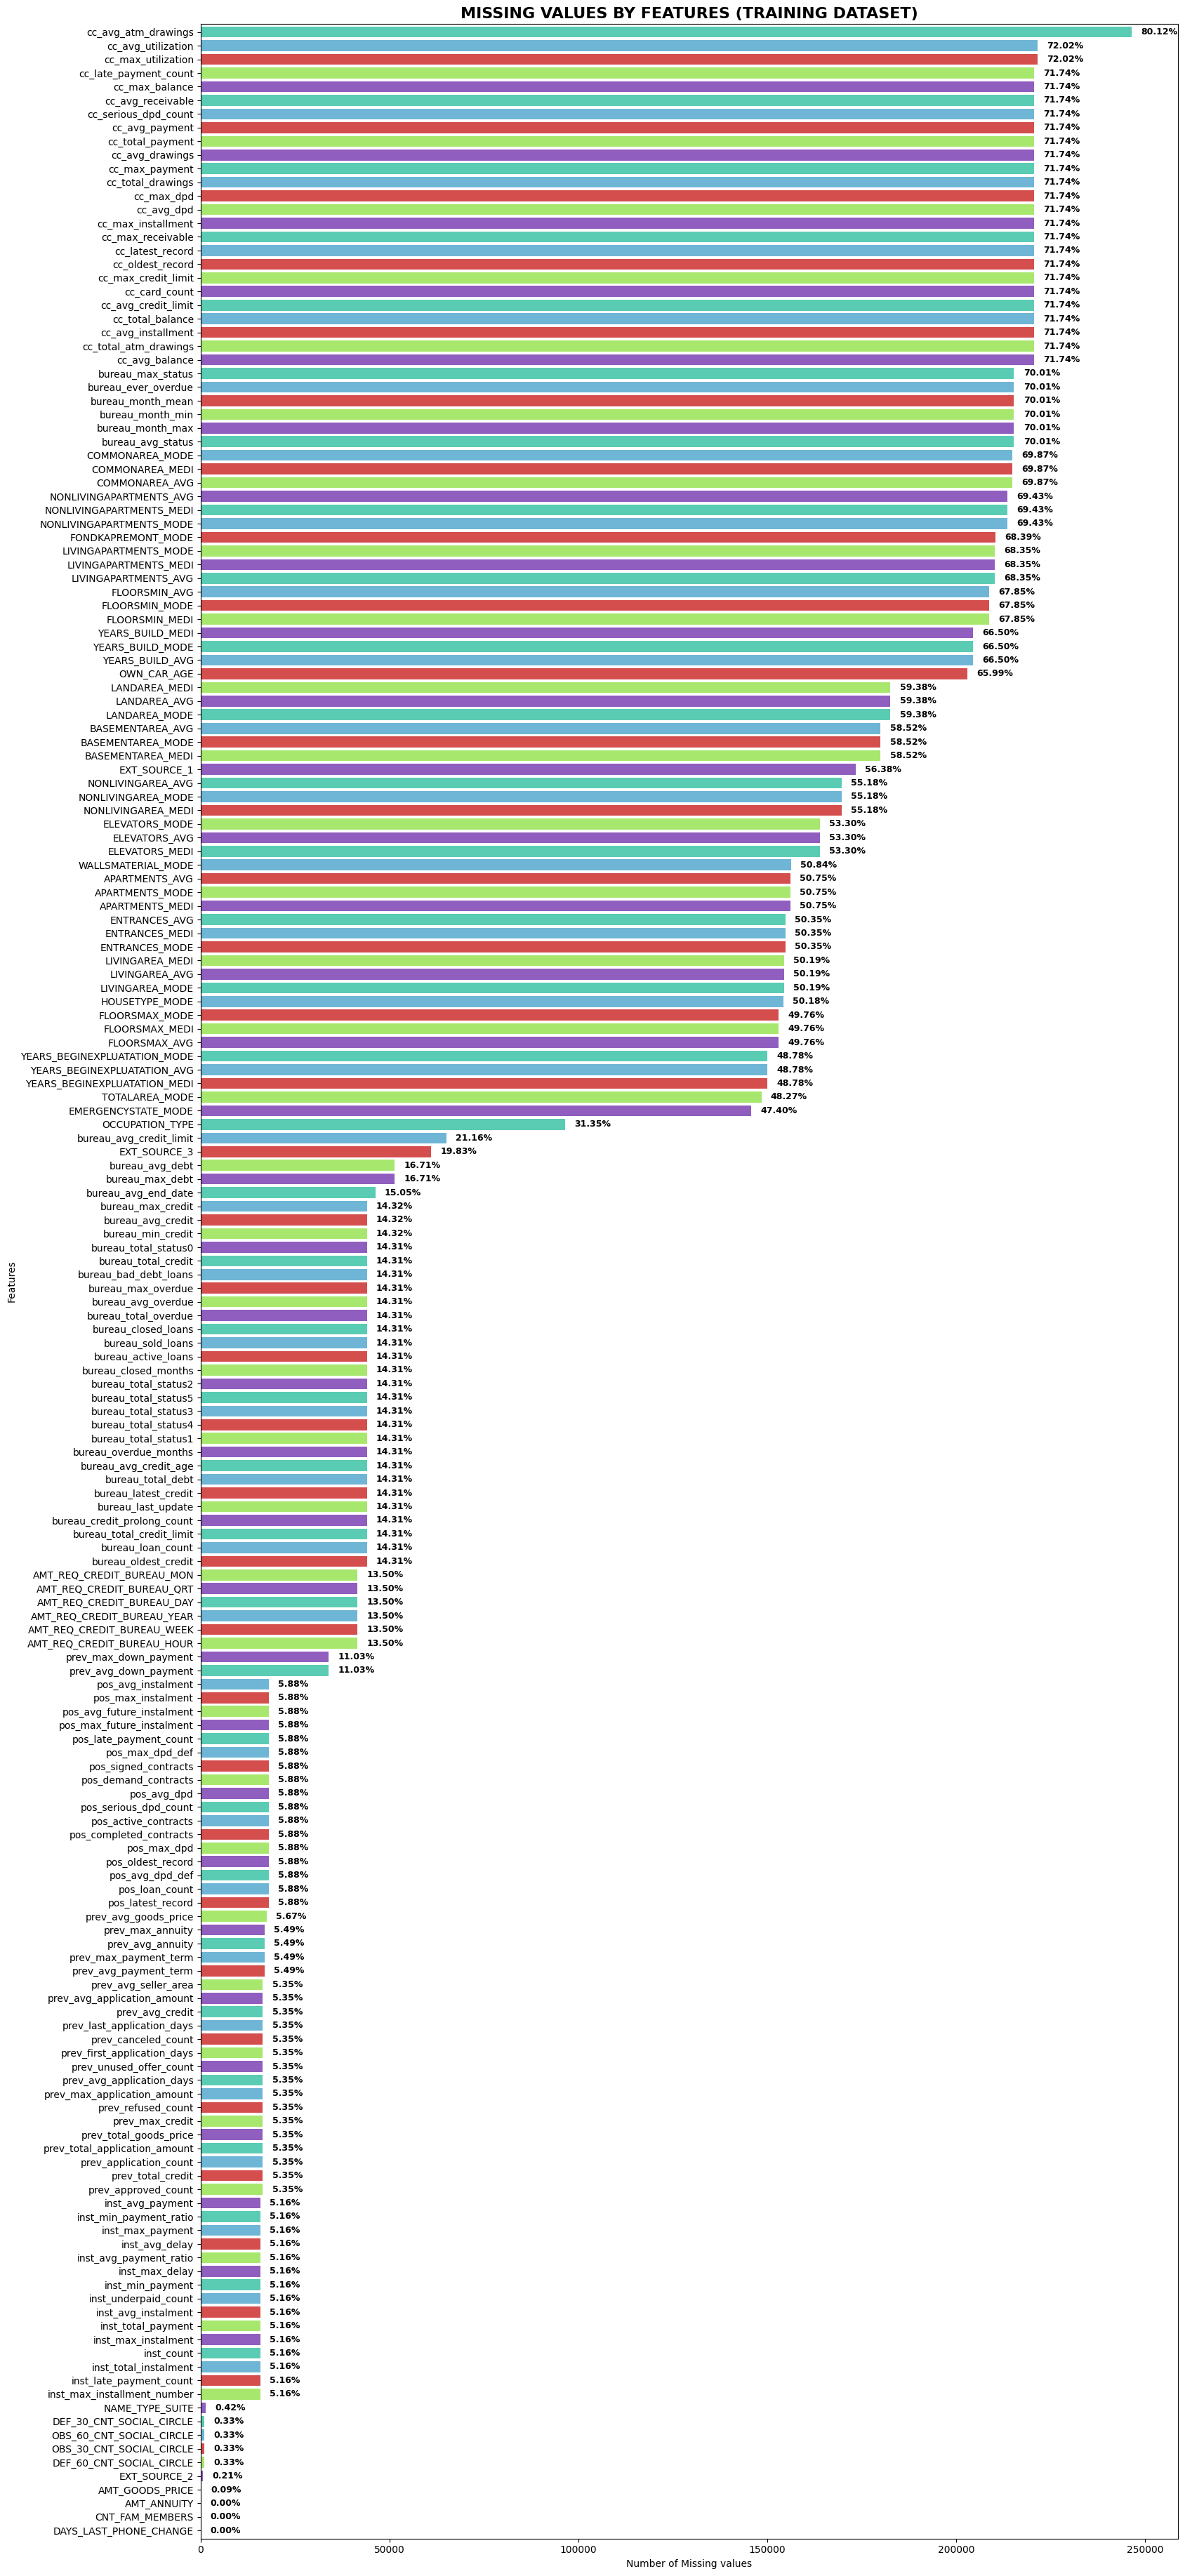

In [8]:
# Missing values in train dataset
Missing_value_plotter(
        train_df, 
        "Number of Missing values", 
        "Features",
        "MISSING VALUES BY FEATURES (TRAINING DATASET)")

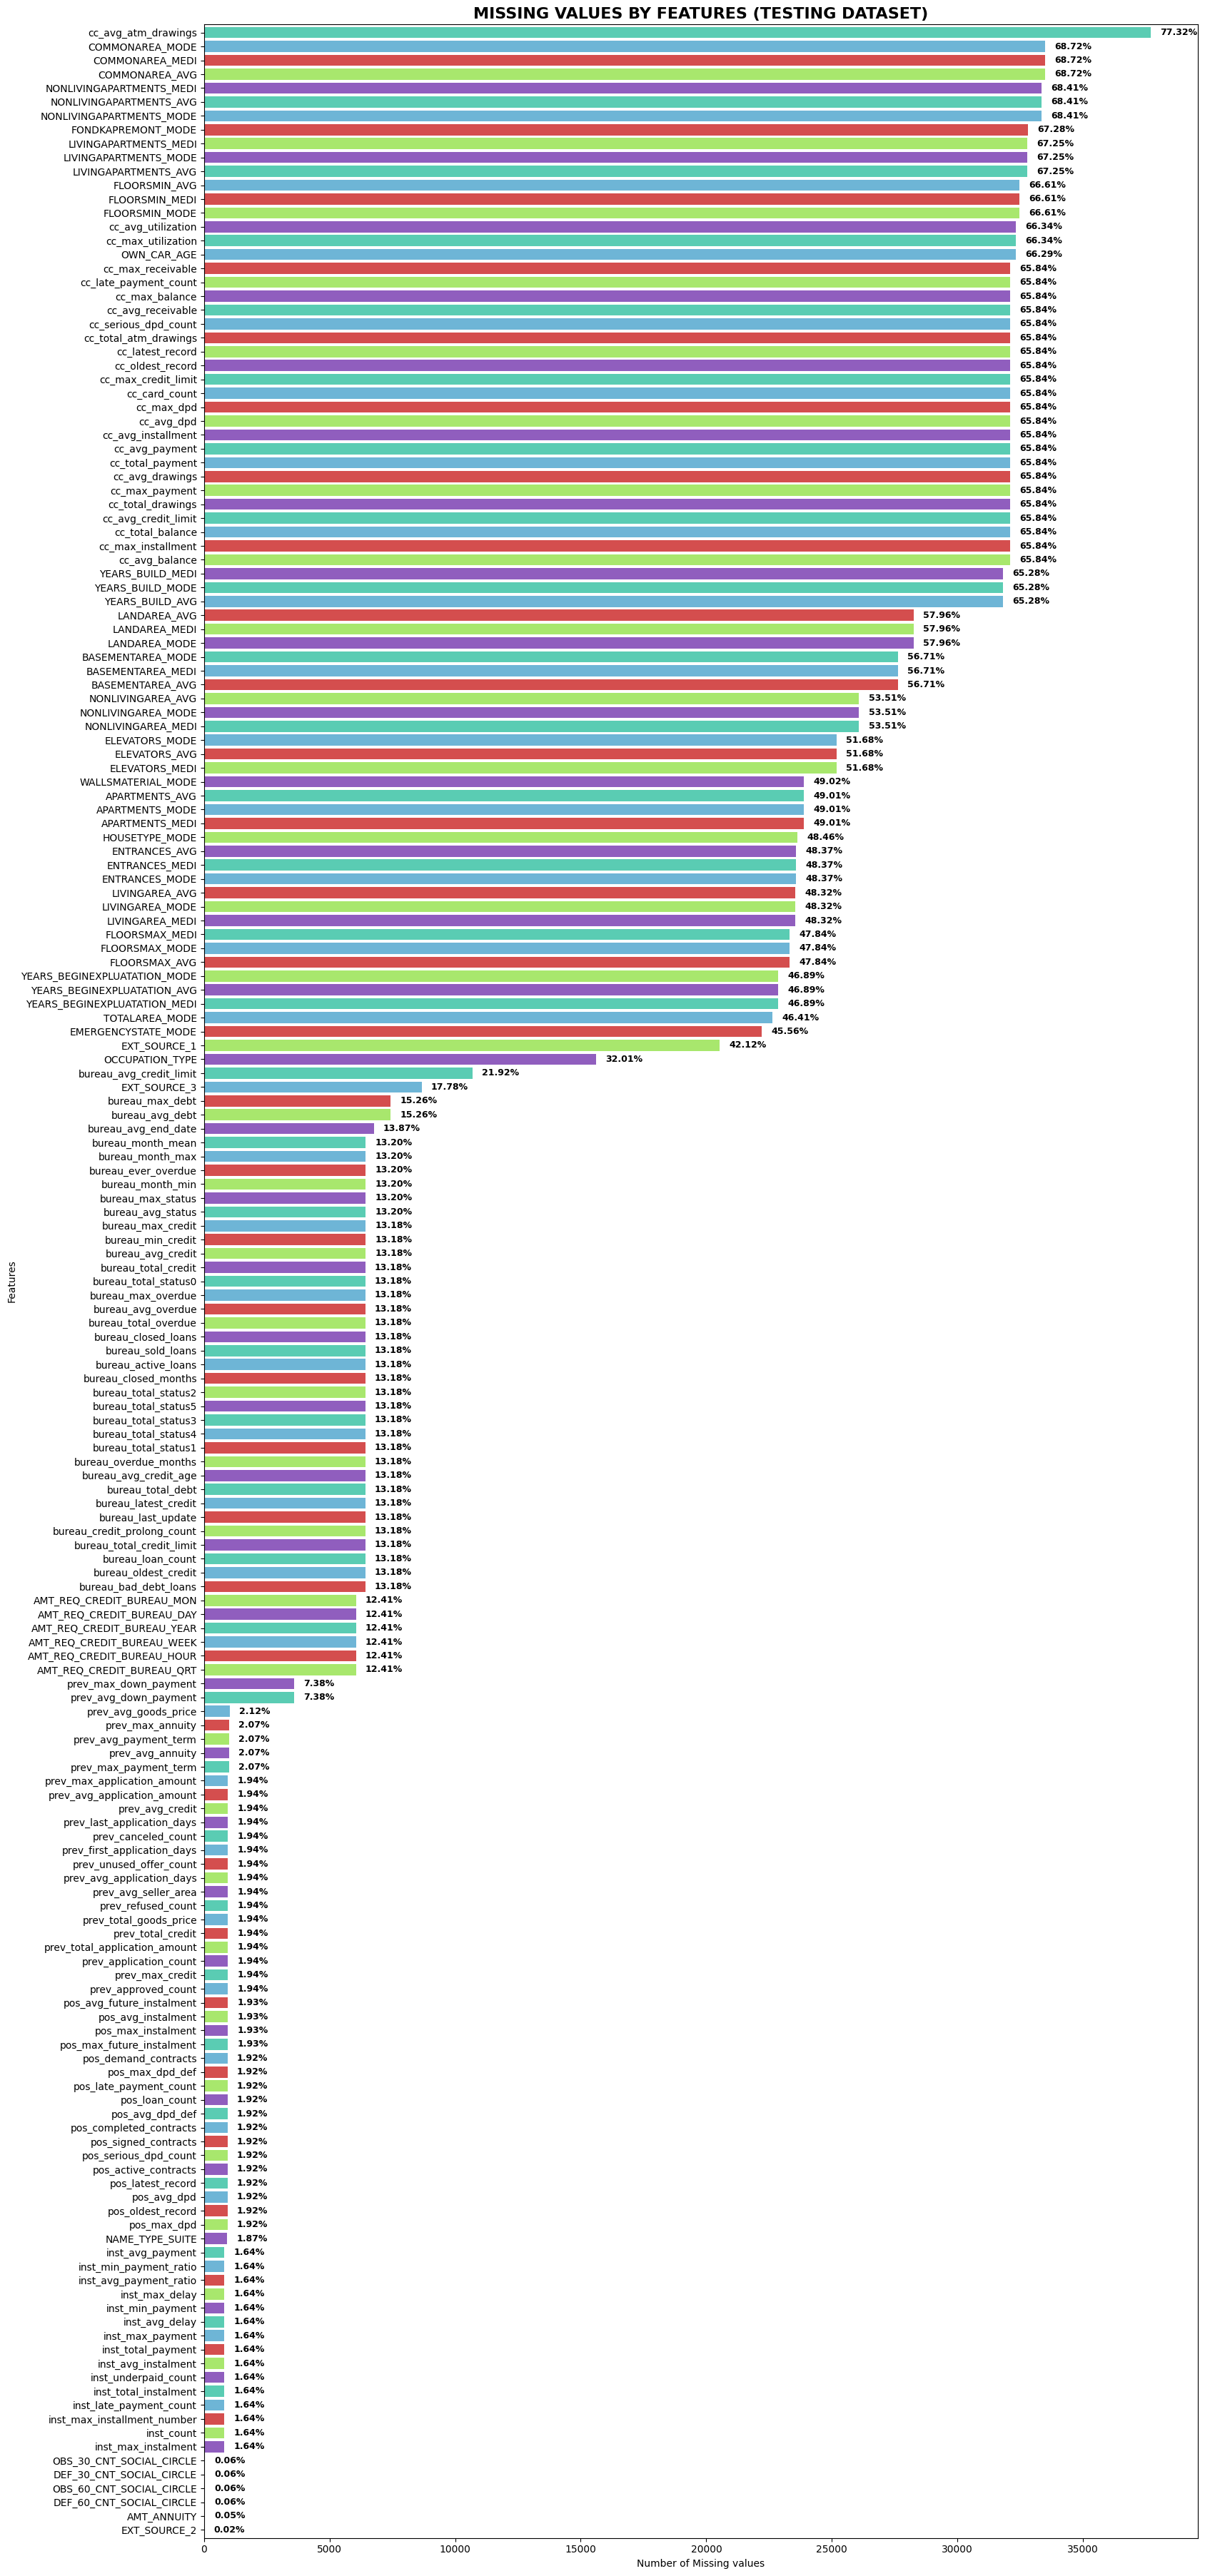

In [9]:
# Missing values in test dataset
Missing_value_plotter(
        test_df, 
        "Number of Missing values", 
        "Features",
        "MISSING VALUES BY FEATURES (TESTING DATASET)")

---
### **7. TARGET COLUMN DISTRIBUTION**

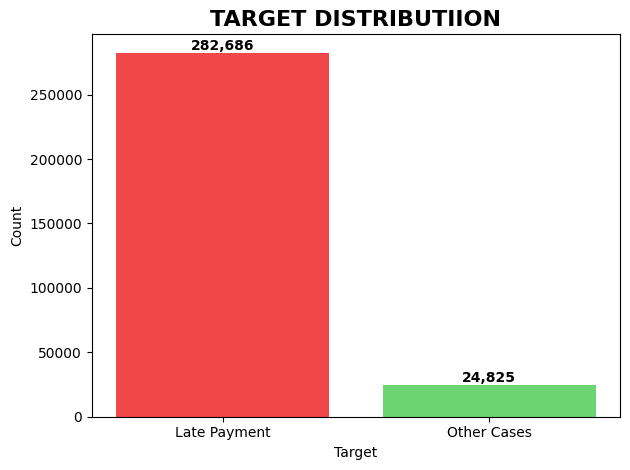

In [10]:
counts = train_df["TARGET"].value_counts().sort_index()
bars = plt.bar(counts.index.astype('str'), counts.values, color=["#F04848", "#6CD471"])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha = "center",
        va = "bottom",
        fontsize = 10,
        fontweight = 'bold',

    )

plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks([0, 1], ["Late Payment", "Other Cases"])
plt.title("TARGET DISTRIBUTIION", fontsize= 16, fontweight = 'bold')
plt.tight_layout()


---
### **8. FEATURE TYPE SUMMARY**

In [11]:
# Function to return the count of columns of different types
def feature_summary(dataset, dataset_name): 
    # Stores columns of numeric type   
    numeric_cols = dataset.select_dtypes(include=['number']).columns
    # Stores columns of boolean type
    boolean_cols = dataset.select_dtypes(include= ['bool']).columns
    # Stores columns of string type
    str_cols = dataset.select_dtypes(include = ['str']).columns
    # Stores columns containing boolean value in string type
    str_bool_cols = [
        col for col in str_cols
        if set(dataset[col].dropna().unique()) <= {"True", "False"}
    ]
    # Storing columns containing string type excluding the columns in 'str_bool_cols'
    categorical_cols = [
        col for col in str_cols
        if col not in str_bool_cols
    ]

    console.print(f'''
        {'-' * 41}
          [#FF7F0E]FEATURES SUMMARY OF  {dataset_name} DATASET[/]
        {'-' * 41}
          [#9467BD]Numeric Columns Count       :[/]   [#1F77B4]{len(numeric_cols)}
          [#9467BD]Categorial Columns Count    :[/]   {len(categorical_cols)}
          [#9467BD]Boolean Columns Count       :[/]   {len(boolean_cols)}[/]
        {'-' * 41}
    ''')

    plt.figure(figsize=(5,5))

# feature summary for training dataset
feature_summary(train_df, 'TRAINING')
# feature summary for testing dataset
feature_summary(test_df, 'TESTING')

-----------------------------------------
          FEATURES SUMMARY OF  TRAINING DATASET
        -----------------------------------------
          Numeric Columns Count       :   223
          Categorial Columns Count    :   16
          Boolean Columns Count       :   0
        -----------------------------------------

-----------------------------------------
          FEATURES SUMMARY OF  TESTING DATASET
        -----------------------------------------
          Numeric Columns Count       :   222
          Categorial Columns Count    :   16
          Boolean Columns Count       :   0
        -----------------------------------------

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

---
### **9. DESCRIPTIVE SUMMARY**

In [12]:
train_df.describe()
# Two features having infinty values

c:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,pos_avg_dpd,pos_max_dpd,pos_avg_dpd_def,pos_max_dpd_def,pos_late_payment_count,pos_serious_dpd_count,pos_active_contracts,pos_completed_contracts,pos_signed_contracts,pos_demand_contracts
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000,289444.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,4.406493,15.697644,0.214863,1.468830,0.895189,0.342415,27.012400,2.193419,0.257822,0.021109
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,60.388372,153.169246,12.926305,30.609586,4.877667,1.572556,22.516351,3.136831,0.722175,1.050490
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,1.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,2.000000,0.000000,0.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.000000,3.000000,0.000000,0.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,2622.078431,4231.000000,1740.554455,3373.000000,120.000000,120.000000,271.000000,85.000000,71.000000,134.000000


In [13]:
test_df.describe()
# One feature having infinity value

c:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,pos_avg_dpd,pos_max_dpd,pos_avg_dpd_def,pos_max_dpd_def,pos_late_payment_count,pos_serious_dpd_count,pos_active_contracts,pos_completed_contracts,pos_signed_contracts,pos_demand_contracts
count,48744.000000,48744.000000,4.874400e+04,4.874400e+04,48720.000000,4.874400e+04,48744.000000,48744.000000,48744.000000,48744.000000,...,47808.000000,47808.000000,47808.000000,47808.000000,47808.000000,47808.000000,47808.000000,47808.000000,47808.000000,47808.000000
mean,277796.676350,0.397054,1.784318e+05,5.167404e+05,29426.240209,4.626188e+05,0.021226,-16068.084605,67485.366322,-4967.652716,...,3.628952,12.850966,0.289685,1.500753,0.755522,0.310806,27.872783,2.301100,0.264286,0.019976
std,103169.547296,0.709047,1.015226e+05,3.653970e+05,16016.368315,3.367102e+05,0.014428,4325.900393,144348.507136,3552.612035,...,55.476748,139.760535,16.865759,41.281338,4.422786,1.915064,23.949533,3.338029,0.729217,1.211380
min,100001.000000,0.000000,2.694150e+04,4.500000e+04,2295.000000,4.500000e+04,0.000253,-25195.000000,-17463.000000,-23722.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,188557.750000,0.000000,1.125000e+05,2.606400e+05,17973.000000,2.250000e+05,0.010006,-19637.000000,-2910.000000,-7459.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,1.000000,0.000000,0.000000
50%,277549.000000,0.000000,1.575000e+05,4.500000e+05,26199.000000,3.960000e+05,0.018850,-15785.000000,-1293.000000,-4490.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,2.000000,0.000000,0.000000
75%,367555.500000,1.000000,2.250000e+05,6.750000e+05,37390.500000,6.300000e+05,0.028663,-12496.000000,-296.000000,-1901.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,37.000000,3.000000,0.000000,0.000000
max,456250.000000,20.000000,4.410000e+06,2.245500e+06,180576.000000,2.245500e+06,0.072508,-7338.000000,365243.000000,0.000000,...,2095.786885,4108.000000,1678.357724,3595.000000,169.000000,169.000000,230.000000,86.000000,42.000000,144.000000


---
### **10. REMOVING ANY INFINITIES**

In [14]:
# Cunstom function to visualize & remove any infinities
def infinity_finder(dataset, dataset_name):
    # Storing numeric columns    
    numeric = dataset.select_dtypes(include=['number'])
    # Storing numeric columns having infinty values
    inf_cols = numeric.columns[np.isinf(numeric).any()]
    # Converting feature name from dictionary to list
    inf_cols.tolist()
    # Visualization
    console.print(f"{'-' * 40}\n  [bold #FF7F0E]INFITIES IN {dataset_name} DATASET[/]\n{'-' * 40}")
    if (np.isinf(numeric.values).any()):
        for col in inf_cols:
            console.print(f"[#D62728]{col}: [#1F77B4]{np.isinf(dataset[col]).sum()} infinities")
        # Replacing infinity to NaN
        dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
    else: console.print("[bold #2CA02C] No infinity Value found !")

# Removing infinity for training dataset
infinity_finder(train_df, 'TRAINING')
# Removing infinty for testing dataset
infinity_finder(test_df, 'TESTING')

# RUN THIS CELL AGAIN AND YOU WILL FIND NO INFINTIES COUNT DUE TO 'replace = True'

----------------------------------------
  INFITIES IN TRAINING DATASET
----------------------------------------

inst_avg_payment_ratio: 18 infinities

inst_min_payment_ratio: 3 infinities

----------------------------------------
  INFITIES IN TESTING DATASET
----------------------------------------

inst_avg_payment_ratio: 1 infinities

### **11. REMOVING DUPLICATES**

In [15]:
def any_duplicates(dataset, dataset_name):
    
    # If duplicates present
    if dataset.duplicated().any():
        # Visualisation
        console.print(f'''
  {'-' * 40}
    [bold #FF7F0E]DUPLICATES IN {dataset_name} DATASET[/]
  {'-' * 40}
    [bold #D62728]Total Duplicates Found: [#1F77B4]{dataset.duplicated().sum()}[/]
  ''')
        # Removing the Duplicated data
        dataset.drop_duplicates(inplace=True)

        # Final Messege
        console.print("[bold #D62728]Duplicates Removed...")

    # If duplicates not present
    # Visualisation
    else: console.print(f'''
  {'-' * 40}
    [bold #FF7F0E]DUPLICATES IN {dataset_name} DATASET[/]
  {'-' * 40}
    [bold #2CA02C]No Duplicates found ![/]
  ''')

# removing any duplicates for training dataset
any_duplicates(train_df, 'TRAINING')
# removing any duplicates for testing dataset
any_duplicates(test_df, 'TESTING')

----------------------------------------
    DUPLICATES IN TRAINING DATASET
  ----------------------------------------
    No Duplicates found !

----------------------------------------
    DUPLICATES IN TESTING DATASET
  ----------------------------------------
    No Duplicates found !

### **12. REMOVING NEAR/CONSTANTS**

In [16]:
def near_constant_remover(dataset, dataset_name):
    # Set a thresold range
    threshold = 99.5

    near_constant_cols = []

    for col in dataset.columns:
        # Storing frequencies of all columns
        top_freq = dataset[col].value_counts(normalize=True, dropna=False).iloc[0]
        # Storing columns haing frequencies greater then thresold value
        if top_freq >= threshold / 100:
            near_constant_cols.append(col)

    if len(near_constant_cols) == 0:
        console.print(f"FOUND [bold #2CA02C]{len(near_constant_cols)}[/] NEAR/CONSTANT FEATURES IN [bold #FF7F0E]{dataset_name} DATASET[/]")
    else: 
        console.print(f"FOUND [bold #D62728]{len(near_constant_cols)}[/] NEAR/CONSTANT FEATURES IN [bold #FF7F0E]{dataset_name} DATASET[/]")
        print(near_constant_cols)
        # Removing columns stored with higher frequencies than thresold
        dataset.drop(columns=near_constant_cols, inplace=True)
        console.print("[bold #2CA02C] Constants Removed...")

# Removing near/constants for training dataset
near_constant_remover(train_df, 'TRAINING')
# removing near/constants for testing dataset
near_constant_remover(test_df, 'TESTING')


FOUND 16 NEAR/CONSTANT FEATURES IN TRAINING DATASET

['FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']


 Constants Removed...

FOUND 18 NEAR/CONSTANT FEATURES IN TESTING DATASET

['FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']


 Constants Removed...

### **13. DETECTING SKEWNESS**

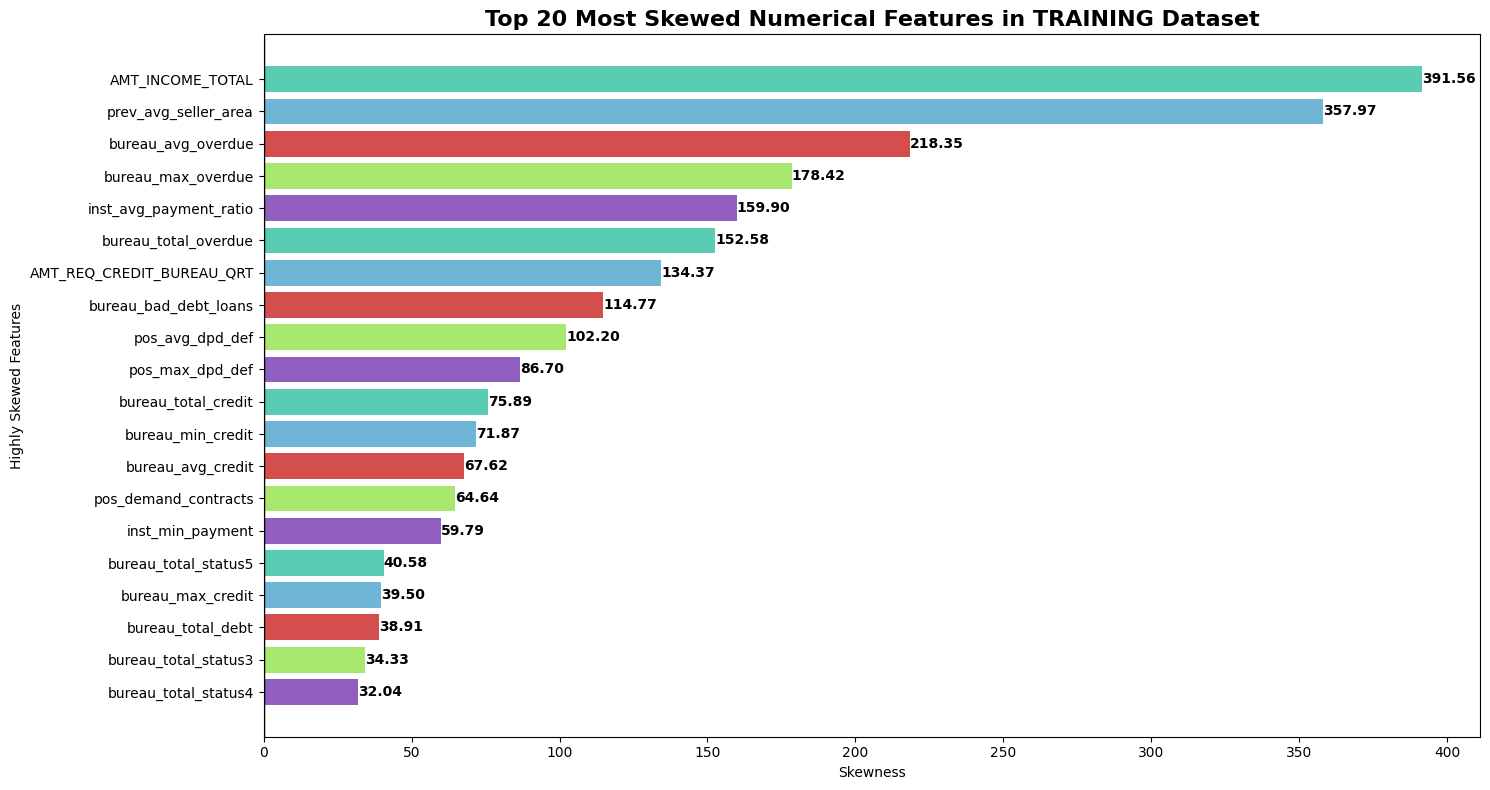

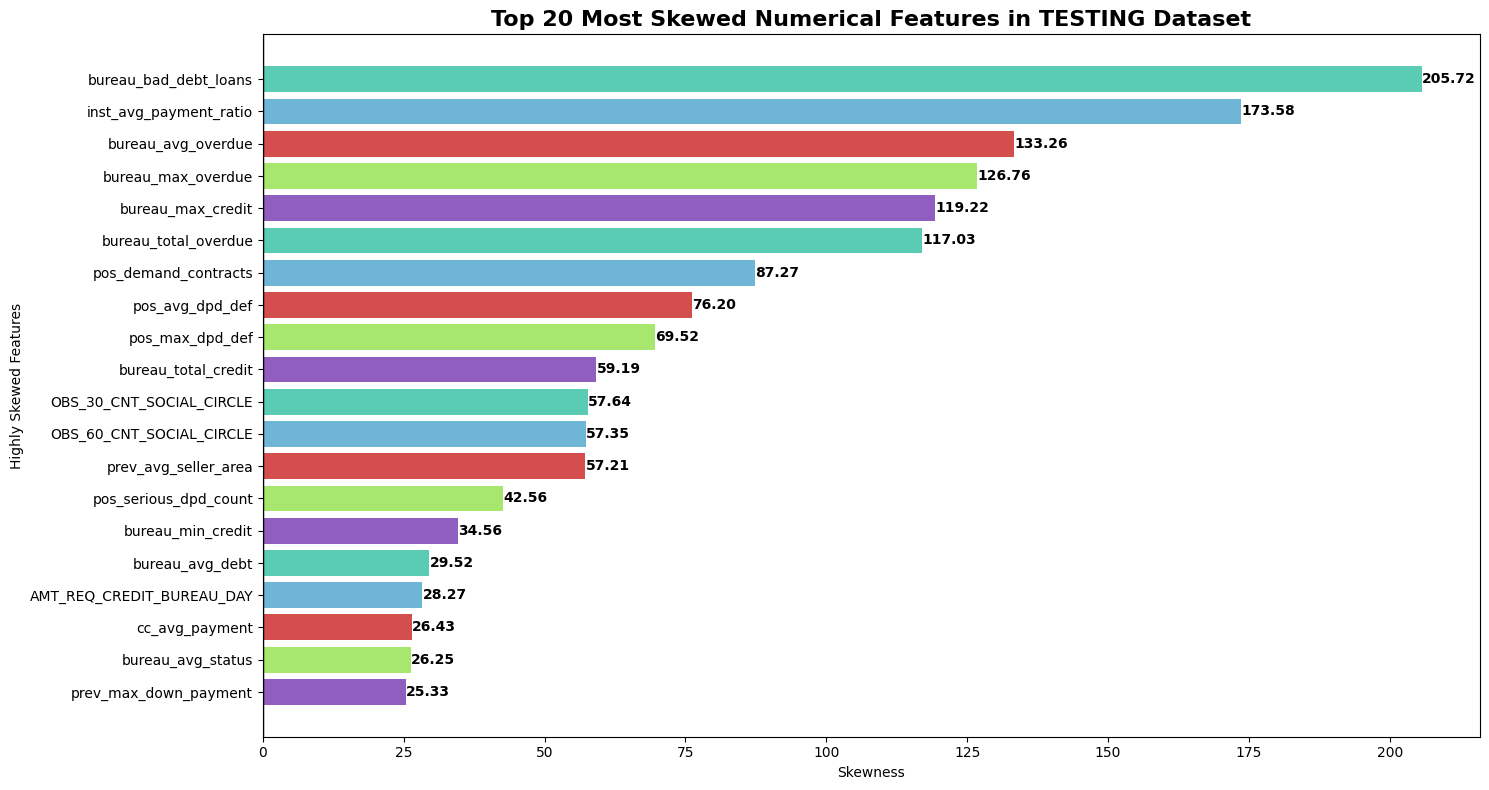

In [17]:
def skew_visualisation(dataset, dataset_name, top_feature):  
    if "TARGET" in dataset.columns:  
        numeric = dataset.select_dtypes(include='number').drop(columns='TARGET')
    else: numeric = dataset.select_dtypes(include='number')

    skewness = (
        numeric.skew()
            .sort_values(key=abs, ascending=False)
            .rename('Skewness')
            .to_frame()
    )

    top_skew = skewness.head(20)

    plt.figure(figsize=(15, 8))

    bars = plt.barh(top_skew.index, top_skew["Skewness"], color=["#5ACCB3", "#6EB5D6", "#D44E4E", "#A8E76D", "#905EBE"])

    for bar in bars:
        width = bar.get_width()

        plt.text(
            width + (0.05 if width >= 0 else -0.5),
            bar.get_y() + bar.get_height()/2,
            f"{width:.2f}",
            va="center",
            fontweight='bold'
        )

    plt.axvline(0, color="black", linewidth=1)

    plt.ylabel("Highly Skewed Features")
    plt.xlabel("Skewness")
    plt.title(f"Top {top_feature} Most Skewed Numerical Features in {dataset_name} Dataset", fontweight='bold', fontsize='16')

    plt.gca().invert_yaxis()
    plt.tight_layout()

skew_visualisation(train_df, 'TRAINING', 20)
skew_visualisation(test_df, 'TESTING', 20)



### **14. CORRELATION HEATMAP OF TRAINING DATASET**

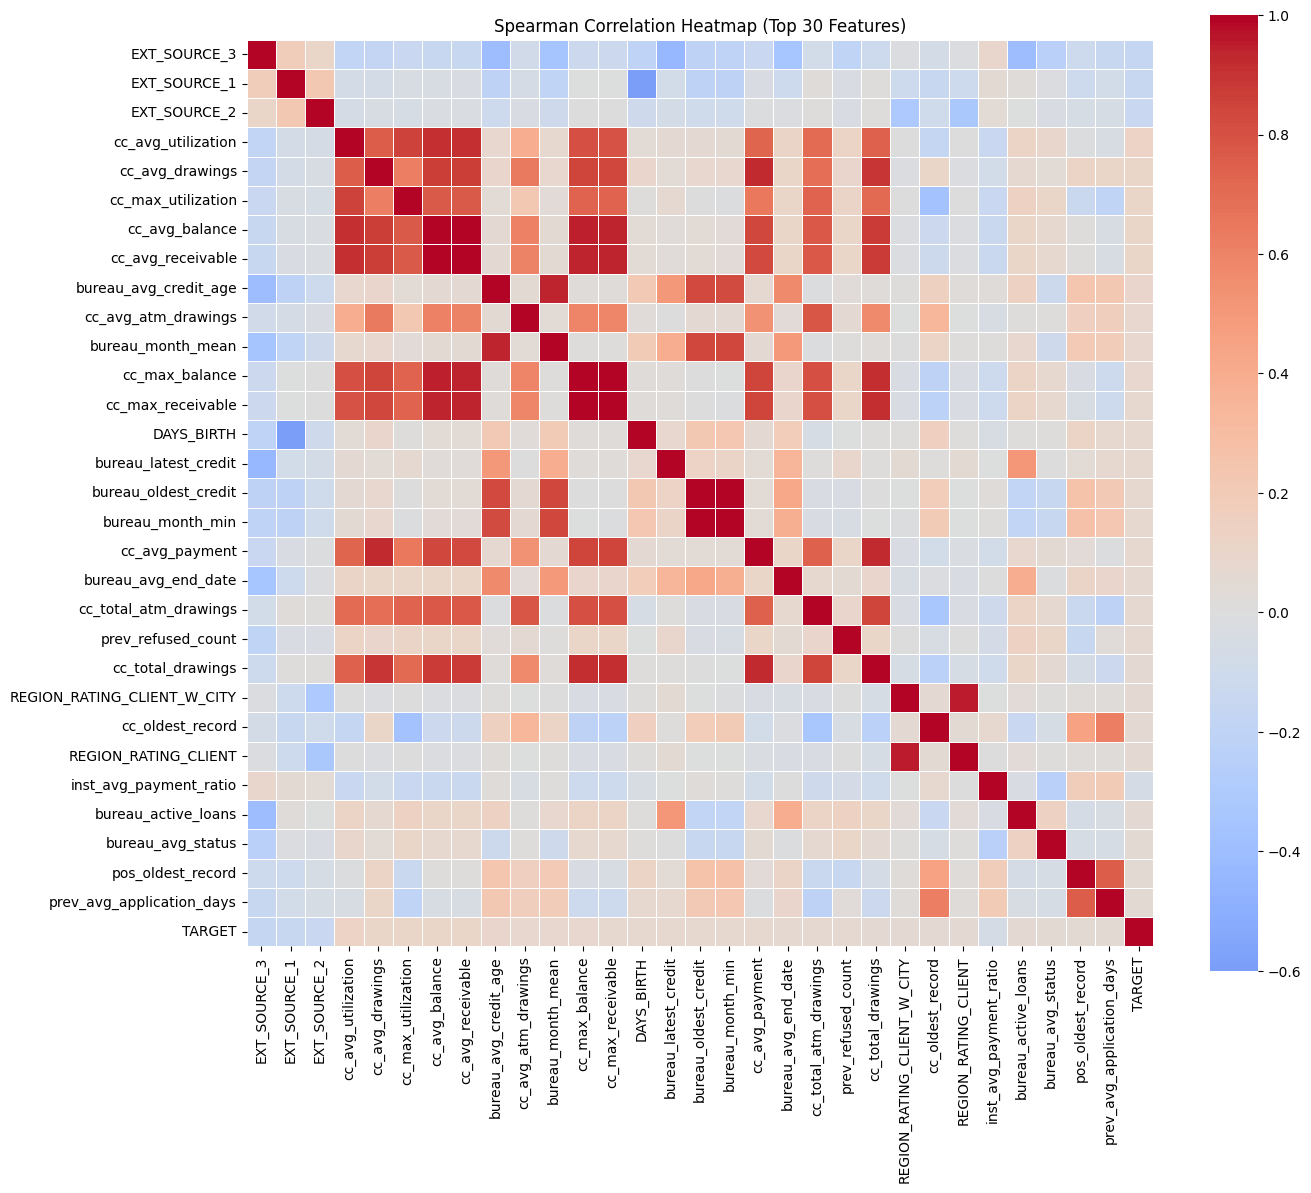

In [18]:
numeric_cols = train_df.select_dtypes(include="number").drop(columns="TARGET").columns

corr_target = (
    train_df[numeric_cols]
    .corrwith(train_df["TARGET"], method="spearman")
    .sort_values(key=abs, ascending=False)
)
top_corr_features = corr_target.head(30).index.to_list()

# Include TARGET in the heatmap
heatmap_cols = top_corr_features + ["TARGET"]



corr_matrix = train_df[heatmap_cols].corr(method="spearman")

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    annot=False,
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap (Top 30 Features)")
plt.tight_layout()

In [19]:
corr_target = (
    train_df[numeric_cols]
    .corrwith(train_df["TARGET"], method="spearman")
    .sort_values(key=abs, ascending=False)
)

top20_features = corr_target.head(30).index.to_list()
top20_features

['EXT_SOURCE_3',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'cc_avg_utilization',
 'cc_avg_drawings',
 'cc_max_utilization',
 'cc_avg_balance',
 'cc_avg_receivable',
 'bureau_avg_credit_age',
 'cc_avg_atm_drawings',
 'bureau_month_mean',
 'cc_max_balance',
 'cc_max_receivable',
 'DAYS_BIRTH',
 'bureau_latest_credit',
 'bureau_oldest_credit',
 'bureau_month_min',
 'cc_avg_payment',
 'bureau_avg_end_date',
 'cc_total_atm_drawings',
 'prev_refused_count',
 'cc_total_drawings',
 'REGION_RATING_CLIENT_W_CITY',
 'cc_oldest_record',
 'REGION_RATING_CLIENT',
 'inst_avg_payment_ratio',
 'bureau_active_loans',
 'bureau_avg_status',
 'pos_oldest_record',
 'prev_avg_application_days']

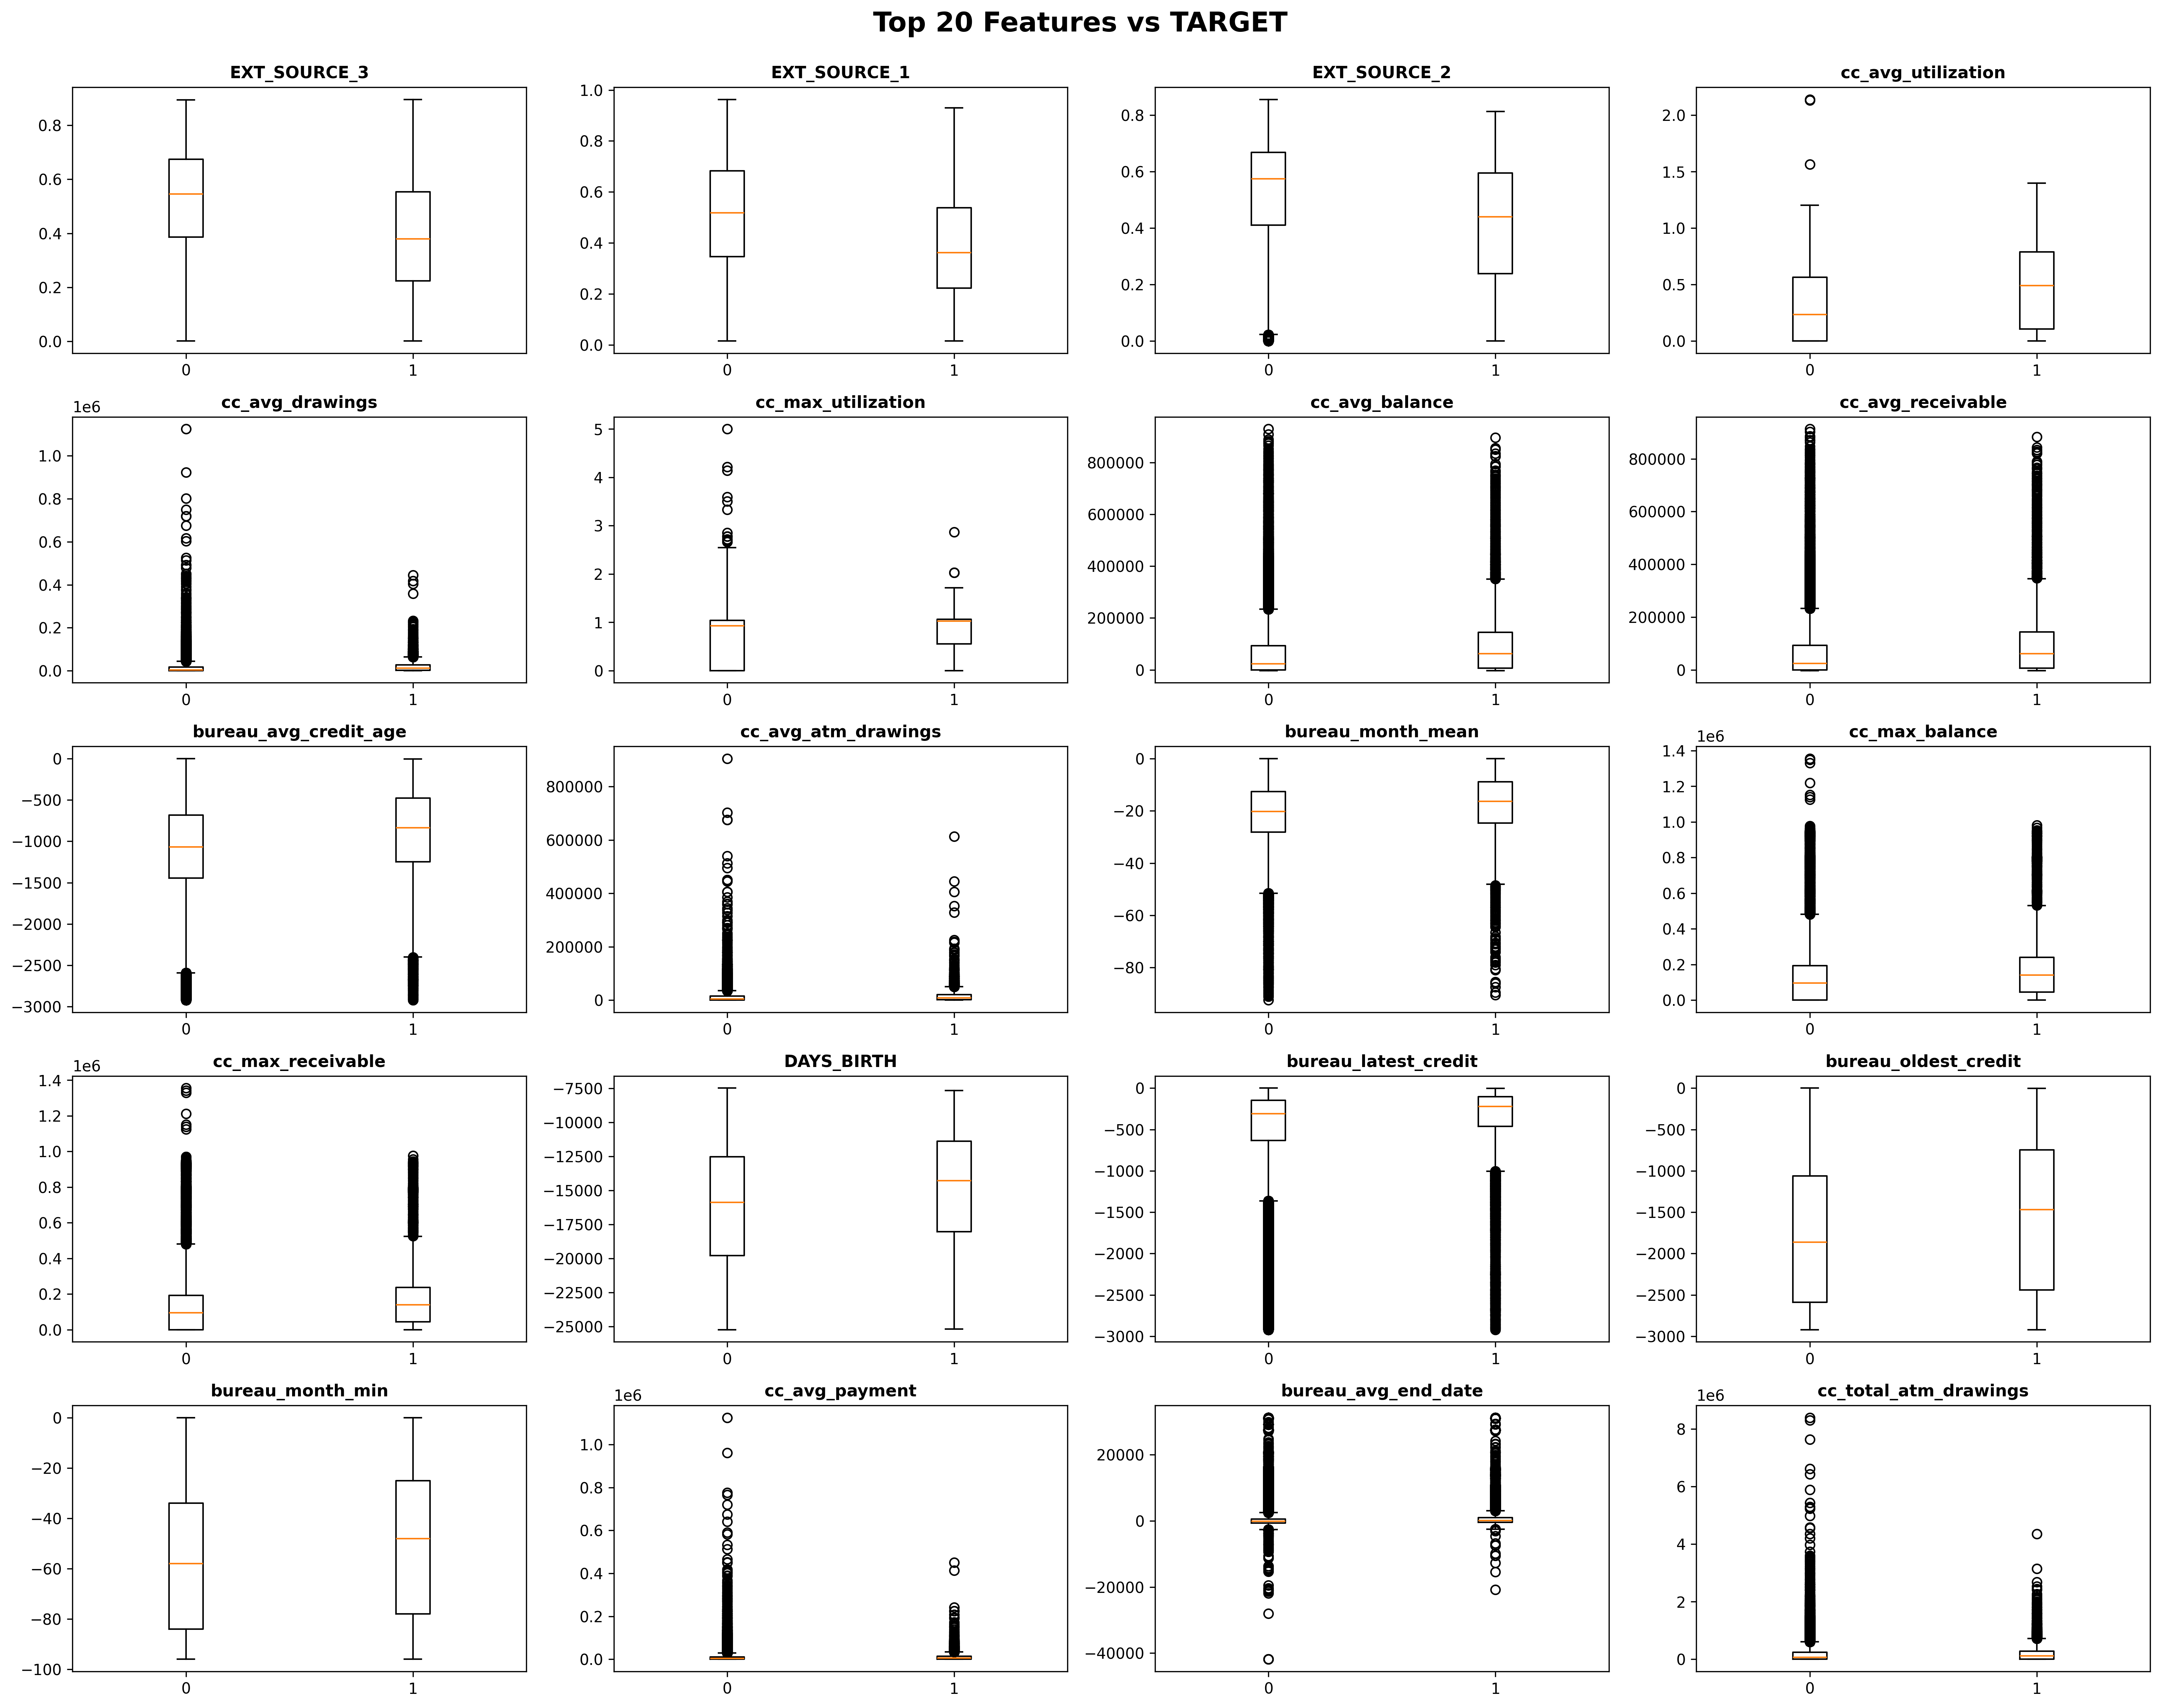

In [20]:
import matplotlib.pyplot as plt

features = top20_features  # Your top 20 features

fig, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(20, 16),
    dpi=300
)

axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.boxplot([
        train_df.loc[train_df["TARGET"] == 0, feature].dropna(),
        train_df.loc[train_df["TARGET"] == 1, feature].dropna()
    ])

    ax.set_xticklabels(["0", "1"])
    ax.set_title(feature, fontsize=11, fontweight='bold')

# Hide any unused subplots
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle("Top 20 Features vs TARGET\n", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
numeric_cols = train_df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q3 - (1.5 * IQR)
    upper_bound = Q1 + (1.5 * IQR)

    outliers = train_df[
        (train_df[col] < lower_bound) |
        (train_df[col] > upper_bound)
    ]

    percentage = len(outliers) / len(train_df) * 100

outliers


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,pos_avg_dpd,pos_max_dpd,pos_avg_dpd_def,pos_max_dpd_def,pos_late_payment_count,pos_serious_dpd_count,pos_active_contracts,pos_completed_contracts,pos_signed_contracts,pos_demand_contracts
1188,101402,0,Cash loans,M,Y,Y,3,90000.0,225000.0,10620.0,...,1.312500,21.0,1.312500,21.0,1.0,1.0,13.0,1.0,0.0,2.0
1223,101444,1,Cash loans,M,N,N,0,99000.0,810000.0,34317.0,...,967.567010,2379.0,967.567010,2379.0,83.0,83.0,28.0,1.0,1.0,27.0
1248,101474,1,Cash loans,F,Y,Y,1,225000.0,576072.0,26986.5,...,1985.049020,3561.0,0.068627,7.0,96.0,1.0,38.0,0.0,0.0,64.0
1580,101851,0,Cash loans,F,N,Y,0,90000.0,900000.0,25794.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,31.0,0.0,0.0,65.0
3287,103838,0,Cash loans,M,Y,Y,0,810000.0,630000.0,59035.5,...,1.857143,8.0,1.523810,8.0,6.0,5.0,18.0,2.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302884,450914,0,Cash loans,M,Y,N,0,225000.0,315000.0,33421.5,...,0.000000,0.0,0.000000,0.0,0.0,0.0,22.0,4.0,0.0,3.0
304476,452763,0,Cash loans,F,N,Y,0,67500.0,659610.0,19417.5,...,193.241935,837.0,0.403226,14.0,30.0,2.0,35.0,2.0,0.0,25.0
305235,453641,1,Cash loans,M,Y,N,2,180000.0,601470.0,32760.0,...,2.764706,22.0,2.764706,22.0,8.0,8.0,28.0,3.0,1.0,2.0
305447,453885,0,Cash loans,F,N,Y,1,90000.0,247275.0,17716.5,...,0.250000,4.0,0.083333,4.0,4.0,1.0,37.0,5.0,1.0,5.0
